<a href="https://colab.research.google.com/github/alsewari/CMP6202-Coursework1/blob/main/CMP6202_Week02_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP6202 Artificial Intelligence and Machine Learning
## Week 2 Lab — From Dataset to Baseline Model (Simple Version)

**Today's idea:** before trying clever models, build a *fair* first experiment.

We will follow 7 small steps:

1. Load the data
2. Look at the data
3. Choose the target (`y`) and the features (`X`)
4. Split the data into train / validation / test
5. Build a **dummy baseline** (a model that does not really learn)
6. Build a **real model** (Logistic Regression)
7. Compare the two, then check on the test set

The goal is **not** a high score. The goal is to understand the steps.

## Assessment connection

Your coursework asks you to build and evaluate an ML model and submit a report plus a GitHub repository (code, data or data instructions, README, report).

The steps in this lab are the same steps you will use in your coursework.

> **Week 2 checkpoint:** by the end of this week, write a first problem statement and find one possible dataset.

## Step 0 — Connect Google Drive

Before you start, put `breast_cancer_wisconsin.csv` (from Moodle: *Week 2 → Datasets for week 2*) into this folder in your Google Drive:

`MyDrive/CMP6202/datasets/`

Dataset source: [Breast Cancer Wisconsin (Diagnostic), UCI](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) — licence CC BY 4.0.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Import libraries and load the data

Each row is one breast tissue sample. Each column is a measurement taken from an image of the sample.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("/content/drive/MyDrive/CMP6202/datasets/breast_cancer_wisconsin.csv")

df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
import seaborn as sns # Seaborn is a useful library for Data Visualisation


<Axes: xlabel='diagnosis', ylabel='count'>

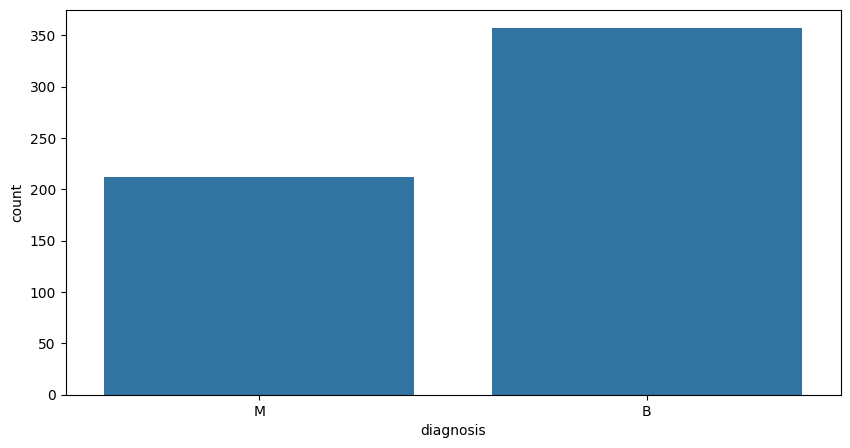

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(df, x ='diagnosis')

The `diagnosis` column uses letters: **M** = malignant, **B** = benign.

Computers prefer numbers, so we make a new column `is_malignant`:

- `1` = malignant (the serious case we want to find)
- `0` = benign

Then we remove `diagnosis` (we replaced it) and `id` (just a number, not a measurement).

In [5]:
df["is_malignant"] = df["diagnosis"].map({"B": 0, "M": 1})

df = df.drop(columns=["diagnosis", "id"])

df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,is_malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


## Step 2 — Look at the data

Always check the size of the data and whether anything is missing.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [ ]:
print("Rows, columns:", df.shape)
print("Missing values:", df.isna().sum().sum())

Rows, columns: (569, 31)
Missing values: 0


In [8]:
df.isna().sum()

,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0
symmetry_mean,0
fractal_dimension_mean,0


In [ ]:
df.isnull().sum

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,is_malignant
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


How many samples are in each class?

is_malignant
0    357
1    212
Name: count, dtype: int64


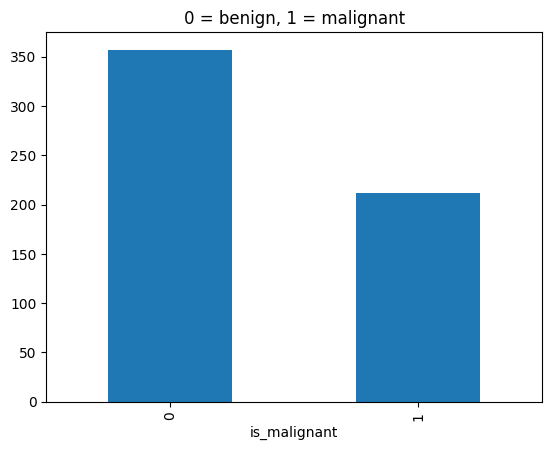

In [ ]:
print(df["is_malignant"].value_counts())

df["is_malignant"].value_counts().plot(kind="bar", title="0 = benign, 1 = malignant")
plt.show()

There are more benign samples than malignant ones. Keep this in mind — it matters in Step 5.

### ✏️ Exercise 1 — Problem statement

Complete this sentence in the cell below:

> Can we predict **[target]** from **[features]** to support **[decision]**?

*Your answer:*

<details>
<summary>Solution — Exercise 1</summary>

> Can we predict **whether a breast tissue sample is malignant** (`is_malignant`) from **30 numeric measurements of the cell nuclei** to support **doctors in deciding which cases need urgent further tests**?

Any answer is fine if it names the target, the features and a real use.
</details>

## Step 3 — Features (`X`) and target (`y`)

- `y` = the column we want to predict (`is_malignant`)
- `X` = everything else (the measurements)

In [9]:
X = df.drop(columns=["is_malignant"])
y = df["is_malignant"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [10]:
y

,is_malignant
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


### ✏️ Exercise 2 — Quick check

1. How many features are in `X`?
2. Is `is_malignant` inside `X`? (It must **not** be!)
3. Is this **classification** or **regression**?

*Your answers:*

<details>
<summary>Solution — Exercise 2</summary>

1. **30 features.**

2. **No** (`False`). Good, because if the answer were inside `X` the model would be "cheating".
3. **Classification.** The target is a category (0 or 1), not a number on a scale.

</details>

## Step 4 — Split the data

We cut the data into three parts:

| Part | Size | Used for |
|---|---|---|
| Train | 60% | the model learns from this |
| Validation | 20% | we compare models on this |
| Test | 20% | one final check at the very end |

`stratify` keeps the same mix of benign/malignant in each part.
`random_state=42` makes sure we get the same split every time.

In [11]:
# Cut 1: take 20% away for the test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Cut 2: split the rest into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 341
Validation: 114
Test: 114


> **Data leakage warning:** never scale or clean the *whole* dataset before splitting.
> Split first, then learn any scaling from the training data only.
> The pipeline in Step 6 does this for us automatically.

[See the video for an example and explanation](https://www.youtube.com/watch?v=UYHCwBUjxeQ)

## Step 5 — Dummy baseline

The dummy model **ignores the features** and always guesses the most common class (benign).

If our real model can't beat this, it is not useful.

### **Check out the following videos explaining Baseline Model**

[Baseline Model](https://www.youtube.com/watch?v=vkRl1-dPuRo)

[Watch this short video for further explanation](https://www.youtube.com/watch?v=ciW_rQaVPBc)

In [13]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)

print("Accuracy:", accuracy_score(y_val, baseline_pred))
print("Recall:  ", recall_score(y_val, baseline_pred))

Accuracy: 0.6228070175438597
Recall:   0.0


- **Accuracy** = how many predictions were right overall.
- **Recall** = of all the real malignant cases, how many did we find?

The confusion matrix shows exactly what happened:

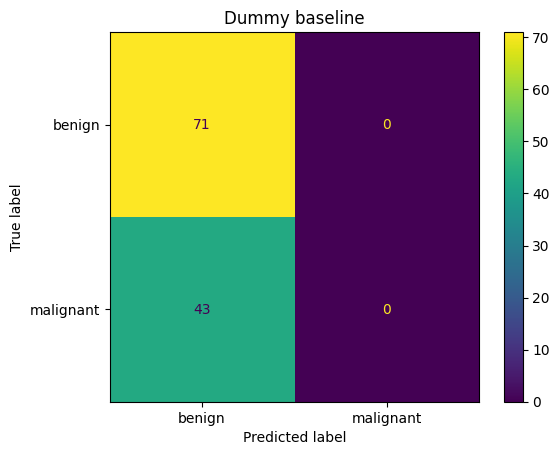

In [14]:
ConfusionMatrixDisplay.from_predictions(y_val, baseline_pred, display_labels=["benign", "malignant"])
plt.title("Dummy baseline")
plt.show()

### ✏️ Exercise 3

1. What does the baseline predict for every sample?
2. The accuracy looks OK — so why is this a bad model? (Hint: look at recall.)

*Your answers:*

<details>
<summary>Solution — Exercise 3</summary>

1. It predicts **benign (0) for every sample**, because benign is the most common class in the training data.
2. Its accuracy is about **0.62** only because about 62% of samples are benign. Its recall is **0.00**: it finds **none** of the malignant cases. For a cancer test, that makes it useless and dangerous.

**Lesson:** high accuracy does not mean a good model when the classes are unbalanced.
</details>

## Step 6 — A real model: Logistic Regression

The measurements are on very different scales (e.g. area ≈ 1000, smoothness ≈ 0.1).
`StandardScaler` puts them on the same scale.

`make_pipeline` joins the scaler and the model together, so the scaler only learns from the training data (no leakage).

In [15]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

model_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, model_pred))
print("Recall:  ", recall_score(y_val, model_pred))

Accuracy: 0.9736842105263158
Recall:   0.9767441860465116


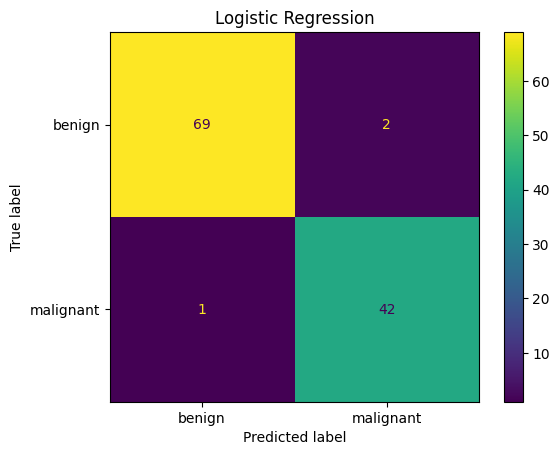

In [16]:
ConfusionMatrixDisplay.from_predictions(y_val, model_pred, display_labels=["benign", "malignant"])
plt.title("Logistic Regression")
plt.show()

### Compare the two models side by side

In [17]:
results = pd.DataFrame({
    "Model":    ["Dummy baseline", "Logistic Regression"],
    "Accuracy": [accuracy_score(y_val, baseline_pred), accuracy_score(y_val, model_pred)],
    "Recall":   [recall_score(y_val, baseline_pred),   recall_score(y_val, model_pred)],
})

results.round(3)

,Model,Accuracy,Recall
0,Dummy baseline,0.623,0.000
1,Logistic Regression,0.974,0.977


### ✏️ Exercise 4

1. Which model is better on the validation set?
2. For cancer diagnosis, which is worse: missing a malignant case, or a false alarm? So which metric matters most?
3. Is the improvement over the baseline big enough to be worth it?

*Your answers:*

<details>
<summary>Solution — Exercise 4</summary>

1. **Logistic Regression is much better.** Accuracy is 0.974 vs 0.623, and recall is 0.977 vs 0.000. It finds 42 of the 43 malignant cases in the validation set.
2. **Recall** matters most. Missing a malignant case (a false negative) could delay treatment. A false alarm (a false positive) usually just leads to more tests.
3. **Yes.** The model goes from finding no malignant cases to finding almost all of them. But the validation set is small (114 samples), so we should still check on the test set. A model like this should **support** doctors, not replace them.

*On the test set, recall is about 0.95 (40 of 42 malignant cases found), so the model holds up on unseen data.*

</details>

## Step 7 — Final check on the test set

We use the test set **only once**, at the very end, after we have chosen our model.

Test accuracy: 0.9736842105263158
Test recall:   0.9523809523809523


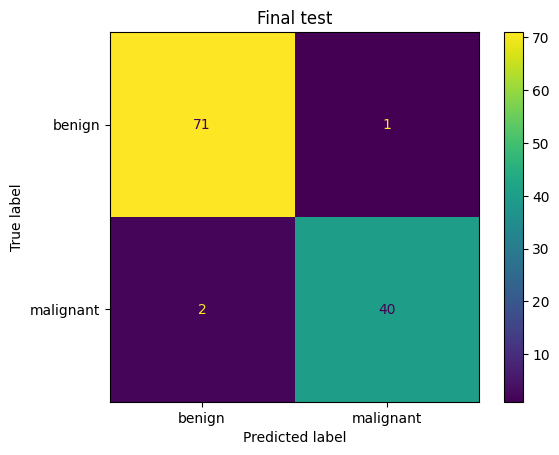

In [18]:
test_pred = model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, test_pred))
print("Test recall:  ", recall_score(y_test, test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["benign", "malignant"])
plt.title("Final test")
plt.show()

## Coursework checkpoint (do before next week)

Pick one possible dataset for your coursework and fill in this table:

| Question | Your answer |
|---|---|
| Dataset name / link | |
| What is one row? | |
| Target (what to predict) | |
| Features (inputs) | |
| Classification or regression? | |
| Dummy baseline | |
| One risk, limitation or ethical issue | |

**Example:** student performance data · one row = one student · target = pass/fail · features = attendance, study time, past marks · classification · always predict "pass" · data may be biased and not fit other cohorts.

[Watch this short video for further explanation](https://www.youtube.com/watch?v=-RZ03WHqkaY)

## GitHub repository — suggested layout

```text
CMP6202-coursework/
├── README.md        ← what the project is and how to run it
├── data/
├── notebooks/
└── report/
```

## Week 2 Lab - Final Message

```text
Load data → Look at data → X and y → Split → Dummy baseline → Real model → Compare → Test once
```

**Next week (Week 3): exploring and preparing data (EDA and preprocessing).**